# DSCI 552 — Homework 2

- **Name:** Danmu Agudanmu
- **GitHub Username:** uudam42

In [19]:
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.dpi"] = 100

## Problem 1: Combined Cycle Power Plant Data Set

### 1(a)
The data was downloaded from the UCI repository and saved in `data/combined_cycle_power_plant/`. Only Sheet 1 is used.

In [21]:
DATA_PATH = "../data/CCPP/Folds5x2_pp.xlsx"
df = pd.read_excel(DATA_PATH, sheet_name=0)

predictors = ["AT", "V", "AP", "RH"]
response = "PE"
df.head()

,AT,V,AP,RH,PE
0,14.9600,41.7600,"1,024.0700",73.1700,463.2600
1,25.1800,62.9600,"1,020.0400",59.0800,444.3700
2,5.1100,39.4000,"1,012.1600",92.1400,488.5600
3,20.8600,57.3200,"1,010.2400",76.6400,446.4800
4,10.8200,37.5000,"1,009.2300",96.6200,473.9000


### 1(b) Exploring the data

#### 1(b)i. Rows and columns

In [23]:
n_rows, n_cols = df.shape
print(f"Rows: {n_rows}, Columns: {n_cols}")
print("Missing values:", df.isna().sum().sum())

Rows: 9568, Columns: 5
Missing values: 0


There are 9568 rows and 5 columns, with no missing values. Each row is one hour of plant operation. The columns are ambient temperature AT (°C), exhaust vacuum V (cm Hg), ambient pressure AP (mbar), relative humidity RH (%), and the response PE, which is the net hourly electrical output (MW).

#### 1(b)ii. Pairwise scatterplots

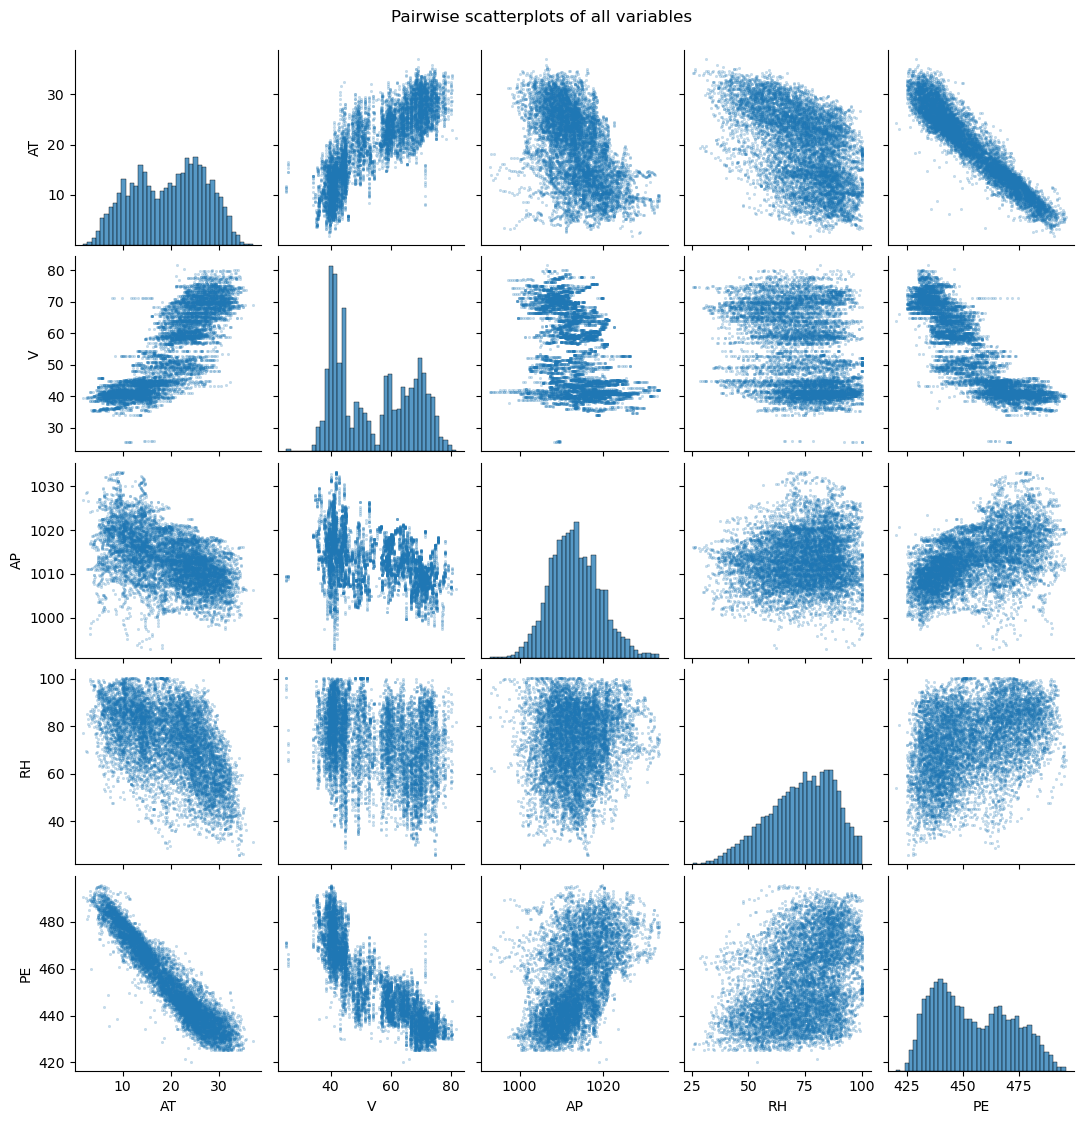

,AT,V,AP,RH,PE
AT,1.0000,0.8440,-0.5080,-0.5430,-0.9480
V,0.8440,1.0000,-0.4140,-0.3120,-0.8700
AP,-0.5080,-0.4140,1.0000,0.1000,0.5180
RH,-0.5430,-0.3120,0.1000,1.0000,0.3900
PE,-0.9480,-0.8700,0.5180,0.3900,1.0000


In [26]:
g = sns.pairplot(df, plot_kws={"s": 4, "alpha": 0.25, "edgecolor": None},
                 diag_kws={"bins": 40}, height=2.2)
g.figure.suptitle("Pairwise scatterplots of all variables", y=1.02)
plt.show()

df.corr().round(3)

PE has a strong negative linear relationship with AT (r = -0.95) and V (r = -0.87). Its relationship with AP (r = 0.52) and RH (r = 0.39) is positive but much weaker, with a lot of scatter. AT and V are also highly correlated with each other (r = 0.84), so there is some collinearity among the predictors.

#### 1(b)iii. Summary statistics

In [29]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Min": df.min(),
    "Max": df.max(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75),
})
summary["IQR"] = summary["Q3"] - summary["Q1"]
summary.round(3)

,Mean,Median,Min,Max,Range,Q1,Q3,IQR
AT,19.6510,20.3450,1.8100,37.1100,35.3000,13.5100,25.7200,12.2100
V,54.3060,52.0800,25.3600,81.5600,56.2000,41.7400,66.5400,24.8000
AP,"1,013.2590","1,012.9400",992.8900,"1,033.3000",40.4100,"1,009.1000","1,017.2600",8.1600
RH,73.3090,74.9750,25.5600,100.1600,74.6000,63.3280,84.8300,21.5020
PE,454.3650,451.5500,420.2600,495.7600,75.5000,439.7500,468.4300,28.6800


The variables are on quite different scales. For example, AP stays within about 40 mbar of its mean of 1013, while RH ranges from 25 to 100.

### 1(c) Simple linear regression for each predictor

In [32]:
simple_models = {}
rows = []
for p in predictors:
    m = smf.ols(f"{response} ~ {p}", data=df).fit()
    simple_models[p] = m
    rows.append({
        "Predictor": p,
        "Intercept": m.params["Intercept"],
        "Slope": m.params[p],
        "Std. Err (slope)": m.bse[p],
        "t-stat": m.tvalues[p],
        "p-value": m.pvalues[p],
        "R^2": m.rsquared,
        "RSE": np.sqrt(m.scale),
    })
simple_table = pd.DataFrame(rows).set_index("Predictor")
simple_table

,Intercept,Slope,Std. Err (slope),t-stat,p-value,R^2,RSE
Predictor,,,,,,,
AT,497.0341,-2.1713,0.0074,-291.7152,0.0000,0.8989,5.4257
V,517.8015,-1.1681,0.0068,-172.4015,0.0000,0.7565,8.4220
AP,"-1,055.2610",1.4899,0.0251,59.2962,0.0000,0.2688,14.5951
RH,420.9618,0.4557,0.0110,41.3987,0.0000,0.1519,15.7179


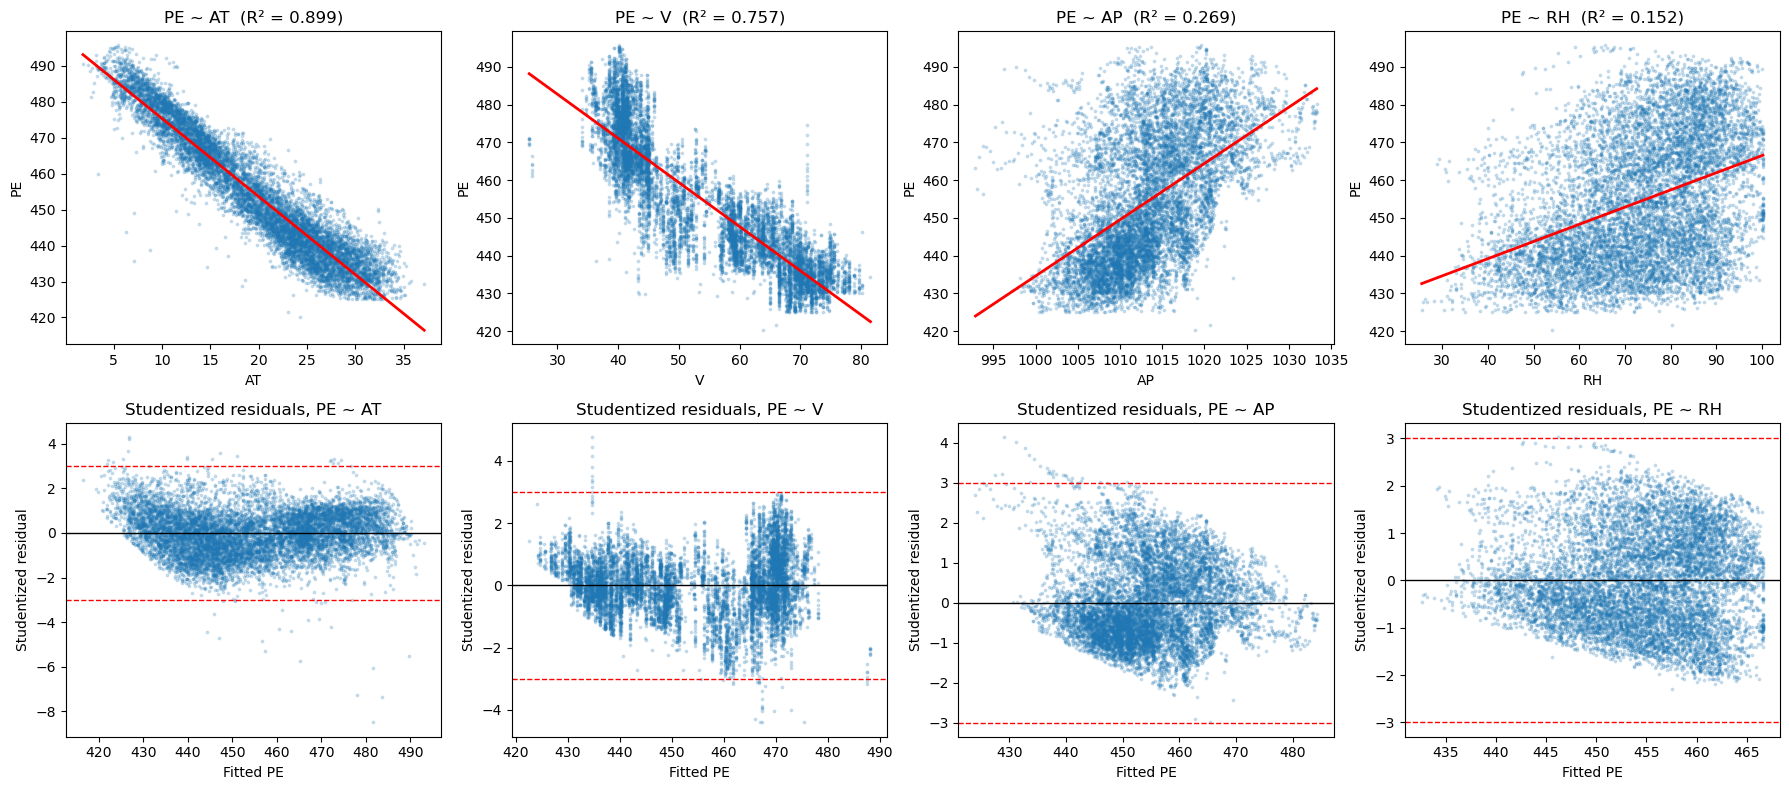

In [33]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for j, p in enumerate(predictors):
    m = simple_models[p]
    ax = axes[0, j]
    ax.scatter(df[p], df[response], s=3, alpha=0.2)
    xs = np.linspace(df[p].min(), df[p].max(), 100)
    ax.plot(xs, m.params["Intercept"] + m.params[p] * xs, color="red", lw=2)
    ax.set_title(f"PE ~ {p}  (R² = {m.rsquared:.3f})")
    ax.set_xlabel(p); ax.set_ylabel("PE")

    ax = axes[1, j]
    ax.scatter(m.fittedvalues, m.get_influence().resid_studentized_external, s=3, alpha=0.2)
    ax.axhline(0, color="k", lw=1)
    ax.axhline(3, color="red", ls="--", lw=1); ax.axhline(-3, color="red", ls="--", lw=1)
    ax.set_title(f"Studentized residuals, PE ~ {p}")
    ax.set_xlabel("Fitted PE"); ax.set_ylabel("Studentized residual")
plt.tight_layout()
plt.show()

All four predictors have a statistically significant association with PE (p-values ≈ 0). AT is the strongest: PE drops about 2.17 MW per °C, and AT alone gives R² = 0.90. V is also strong (R² = 0.76), while AP (R² = 0.27) and RH (R² = 0.15) explain much less. The residual plots for AT and V show some curvature and banding, so the relationships are probably not completely linear.

To check for outliers, I looked at studentized residuals (|r| > 3) and Cook's distance, and refit each model without the large-residual points.

In [35]:
n = len(df)
out_rows = []
for p in predictors:
    m = simple_models[p]
    infl = m.get_influence()
    sr = infl.resid_studentized_external
    lev = infl.hat_matrix_diag
    cooks = infl.cooks_distance[0]
    mask = np.abs(sr) <= 3
    m_clean = smf.ols(f"{response} ~ {p}", data=df[mask]).fit()
    out_rows.append({
        "Predictor": p,
        "# |stud. resid| > 3": int((~mask).sum()),
        "# high leverage (h > 3p/n)": int((lev > 3 * 2 / n).sum()),
        "Max Cook's D": cooks.max(),
        "Slope (all data)": m.params[p],
        "Slope (outliers removed)": m_clean.params[p],
        "R^2 (all data)": m.rsquared,
        "R^2 (outliers removed)": m_clean.rsquared,
    })
pd.DataFrame(out_rows).set_index("Predictor")

,# |stud. resid| > 3,# high leverage (h > 3p/n),Max Cook's D,Slope (all data),Slope (outliers removed),R^2 (all data),R^2 (outliers removed)
Predictor,,,,,,,
AT,42,7,0.0143,-2.1713,-2.1802,0.8989,0.9064
V,33,13,0.0032,-1.1681,-1.1769,0.7565,0.7670
AP,30,239,0.0082,1.4899,1.5401,0.2688,0.2864
RH,2,173,0.0021,0.4557,0.4564,0.1519,0.1526


Each model has a few points with |r| > 3 (less than 0.5% of the data), but the largest Cook's distance is only 0.014 and removing these points barely changes the slopes. They look like real extreme-weather hours rather than errors, so I did not remove any outliers.

### 1(d) Multiple linear regression with all predictors

In [38]:
multi_model = smf.ols("PE ~ AT + V + AP + RH", data=df).fit()
print(multi_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Thu, 24 Sep 2026   Prob (F-statistic):               0.00
Time:                        21:57:32   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

The model has R² = 0.929. All four predictors have p < 0.001, so we can reject H₀: βⱼ = 0 for AT, V, AP and RH.

### 1(e) Comparing simple and multiple regression coefficients

,Simple regression (1c),Multiple regression (1d)
AT,-2.1713,-1.9775
V,-1.1681,-0.2339
AP,1.4899,0.0621
RH,0.4557,-0.1581


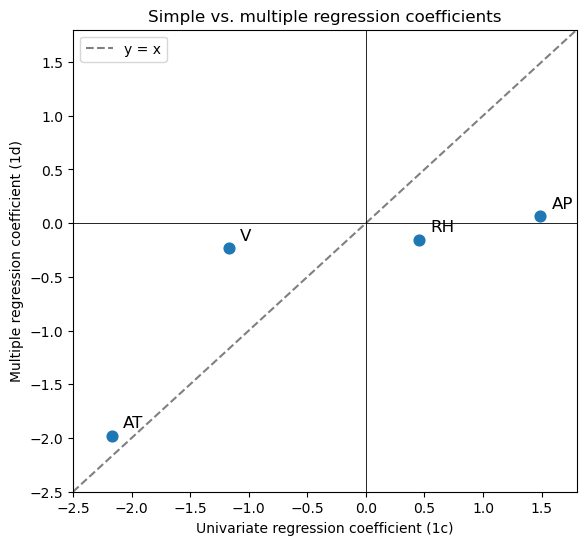

In [41]:
coef_compare = pd.DataFrame({
    "Simple regression (1c)": [simple_models[p].params[p] for p in predictors],
    "Multiple regression (1d)": [multi_model.params[p] for p in predictors],
}, index=predictors)
display(coef_compare)

fig, ax = plt.subplots(figsize=(6.5, 6))
ax.scatter(coef_compare.iloc[:, 0], coef_compare.iloc[:, 1], s=60, color="tab:blue", zorder=3)
for p in predictors:
    ax.annotate(p, (coef_compare.loc[p].iloc[0], coef_compare.loc[p].iloc[1]),
                textcoords="offset points", xytext=(8, 6), fontsize=12)
lims = [-2.5, 1.8]
ax.plot(lims, lims, ls="--", color="gray", label="y = x")
ax.axhline(0, color="k", lw=0.6); ax.axvline(0, color="k", lw=0.6)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Univariate regression coefficient (1c)")
ax.set_ylabel("Multiple regression coefficient (1d)")
ax.set_title("Simple vs. multiple regression coefficients")
ax.legend()
plt.show()

The coefficients change a lot once all predictors are in the same model. AT stays about the same, but V and AP shrink toward 0, and RH changes sign (from 0.46 to -0.16). This is because AT is correlated with the other predictors, so in the simple regressions V, AP and RH were partly picking up the effect of temperature.

### 1(f) Nonlinear association

Since AP is around 1000, AP³ causes numerical problems in the fit. I centered each predictor before adding the squared and cubic terms, which does not change the fitted curve or the p-value of X³.

In [44]:
df_c = df.copy()
for p in predictors:
    df_c[p] = df[p] - df[p].mean()

poly_rows = []
poly_models = {}
for p in predictors:
    lin = smf.ols(f"PE ~ {p}", data=df_c).fit()
    cub = smf.ols(f"PE ~ {p} + I({p}**2) + I({p}**3)", data=df_c).fit()
    poly_models[p] = cub
    f_test = anova_lm(lin, cub)
    poly_rows.append({
        "Predictor": p,
        "p (X)": cub.pvalues[p],
        "p (X^2)": cub.pvalues[f"I({p} ** 2)"],
        "p (X^3)": cub.pvalues[f"I({p} ** 3)"],
        "R^2 linear": lin.rsquared,
        "R^2 cubic": cub.rsquared,
        "F-test p (cubic vs linear)": f_test["Pr(>F)"].iloc[1],
    })
pd.DataFrame(poly_rows).set_index("Predictor")

,p (X),p (X^2),p (X^3),R^2 linear,R^2 cubic,F-test p (cubic vs linear)
Predictor,,,,,,
AT,0.0000,0.0000,0.0000,0.8989,0.9119,0.0000
V,0.0000,0.0000,0.0137,0.7565,0.7750,0.0000
AP,0.0000,0.0000,0.0000,0.2688,0.2975,0.0000
RH,0.0000,0.1014,0.0000,0.1519,0.1537,0.0000


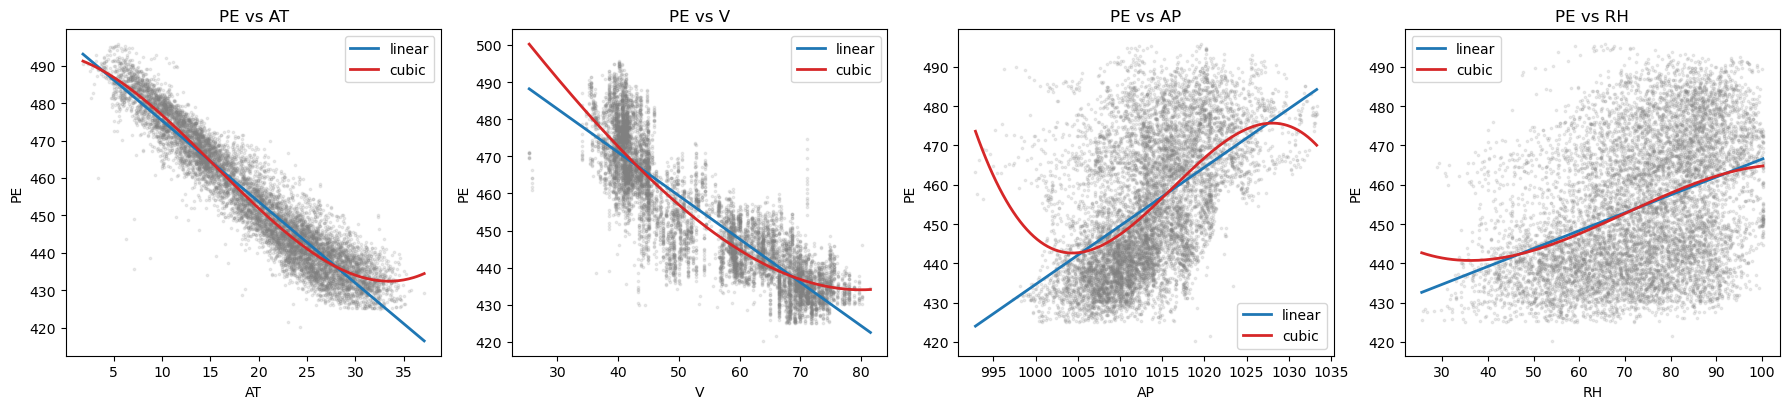

In [45]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
for ax, p in zip(axes, predictors):
    lin = simple_models[p]
    cub = poly_models[p]
    xs = np.linspace(df[p].min(), df[p].max(), 200)
    xs_c = pd.DataFrame({p: xs - df[p].mean()})
    ax.scatter(df[p], df[response], s=3, alpha=0.15, color="gray")
    ax.plot(xs, lin.params["Intercept"] + lin.params[p] * xs, color="tab:blue", lw=2, label="linear")
    ax.plot(xs, cub.predict(xs_c), color="tab:red", lw=2, label="cubic")
    ax.set_xlabel(p); ax.set_ylabel("PE"); ax.set_title(f"PE vs {p}")
    ax.legend()
plt.tight_layout()
plt.show()

Yes. The X³ term is significant for every predictor, and the F-test rejects the linear model in all four cases. The improvement is noticeable for AT (R² from 0.899 to 0.912), V (0.757 to 0.775) and AP (0.269 to 0.298), but very small for RH (0.152 to 0.154).

### 1(g) Interactions: full model with all pairwise interaction terms

In [48]:
inter_model = smf.ols("PE ~ (AT + V + AP + RH)**2", data=df).fit()
print(inter_model.summary().tables[1])
print(f"R^2 = {inter_model.rsquared:.4f}  (additive model in 1d: {multi_model.rsquared:.4f})")

inter_terms = [t for t in inter_model.params.index if ":" in t]
pd.DataFrame({
    "coef": inter_model.params[inter_terms],
    "p-value": inter_model.pvalues[inter_terms],
    "significant at 0.05": inter_model.pvalues[inter_terms] < 0.05,
})

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.000     531.631     839.934
AT            -4.3470      2.373     -1.832      0.067      -8.999       0.305
V             -7.6749      1.351     -5.682      0.000     -10.323      -5.027
AP            -0.1524      0.077     -1.983      0.047      -0.303      -0.002
RH             1.5709      0.773      2.031      0.042       0.055       3.087
AT:V           0.0210      0.001     23.338      0.000       0.019       0.023
AT:AP          0.0018      0.002      0.752      0.452      -0.003       0.006
AT:RH         -0.0052      0.001     -6.444      0.000      -0.007      -0.004
V:AP           0.0068      0.001      5.135      0.000       0.004       0.009
V:RH           0.0008      0.000      1.716      0.086      -0.000       0.002
AP:RH         -0.0016      0.001     -2.125      0.0

,coef,p-value,significant at 0.05
AT:V,0.0210,0.0000,True
AT:AP,0.0018,0.4521,False
AT:RH,-0.0052,0.0000,True
V:AP,0.0068,0.0000,True
V:RH,0.0008,0.0862,False
AP:RH,-0.0016,0.0336,True


Four interaction terms are significant at the 5% level: AT:V, AT:RH, V:AP and AP:RH. AT:AP (p = 0.45) and V:RH (p = 0.09) are not significant.

### 1(h) Improving the model

I used a random 70/30 train/test split. Model A uses only the four predictors. Model B starts with all main effects, pairwise interactions and squared terms, then removes the least significant term one at a time until every p-value is below 0.05. A main effect is kept as long as it still appears in an interaction or squared term in the model.

In [51]:
train, test = train_test_split(df, test_size=0.3, random_state=552)
train, test = train.copy(), test.copy()
print(f"Train size: {len(train)}, Test size: {len(test)}")

def mse(y, yhat):
    return mean_squared_error(y, yhat)

# Model A: all predictors, linear
model_a = smf.ols("PE ~ AT + V + AP + RH", data=train).fit()
a_train, a_test = mse(train.PE, model_a.predict(train)), mse(test.PE, model_a.predict(test))
print(f"Model A  train MSE = {a_train:.3f}, test MSE = {a_test:.3f}")

Train size: 6697, Test size: 2871
Model A  train MSE = 20.355, test MSE = 21.741


In [52]:
# Build interaction and squared columns explicitly so term names are easy to track
pairs = list(itertools.combinations(predictors, 2))
for d in (train, test):
    for a, b in pairs:
        d[f"{a}_x_{b}"] = d[a] * d[b]
    for p in predictors:
        d[f"{p}_sq"] = d[p] ** 2

def parents(term):
    # main effects a higher-order term depends on
    if term.endswith("_sq"):
        return [term[:-3]]
    if "_x_" in term:
        return term.split("_x_")
    return []

terms = predictors + [f"{a}_x_{b}" for a, b in pairs] + [f"{p}_sq" for p in predictors]
removed = []
while True:
    fit = smf.ols("PE ~ " + " + ".join(terms), data=train).fit()
    pvals = fit.pvalues.drop("Intercept")
    protected = {par for t in terms for par in parents(t)}
    eligible = pvals[[t for t in terms if t not in protected]]
    worst = eligible.idxmax()
    if eligible[worst] < 0.05:
        break
    removed.append((worst, eligible[worst]))
    terms.remove(worst)

model_b = fit
print("Removed (in order):")
for t, pv in removed:
    print(f"  {t:10s} p = {pv:.3f}")
print("\nFinal terms:", terms)
print(model_b.summary().tables[1])

Removed (in order):
  AT_x_AP    p = 0.492
  V_x_RH     p = 0.379
  V_sq       p = 0.093

Final terms: ['AT', 'V', 'AP', 'RH', 'AT_x_V', 'AT_x_RH', 'V_x_AP', 'AP_x_RH', 'AT_sq', 'AP_sq', 'RH_sq']
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7943.0909   1227.942     -6.469      0.000   -1.04e+04   -5535.932
AT            -2.7285      0.112    -24.291      0.000      -2.949      -2.508
V             -4.6715      1.088     -4.293      0.000      -6.805      -2.538
AP            16.5076      2.388      6.914      0.000      11.827      21.188
RH             4.0672      0.820      4.960      0.000       2.460       5.675
AT_x_V         0.0083      0.002      5.518      0.000       0.005       0.011
AT_x_RH       -0.0044      0.001     -4.773      0.000      -0.006      -0.003
V_x_AP         0.0042      0.001      3.905      0.000       0.002       0.006
AP_x_RH       

In [53]:
b_train, b_test = mse(train.PE, model_b.predict(train)), mse(test.PE, model_b.predict(test))
results_h = pd.DataFrame({
    "Train MSE": [a_train, b_train],
    "Test MSE": [a_test, b_test],
    "# terms": [4, len(terms)],
}, index=["A: linear, all predictors", "B: interactions + quadratics (reduced)"])
results_h

,Train MSE,Test MSE,# terms
"A: linear, all predictors",20.3547,21.7414,4
B: interactions + quadratics (reduced),17.7087,19.0829,11


Three terms were removed: AT:AP, V:RH and V². Model B lowers the test MSE from 21.74 to 19.08. Its gap between train and test MSE is about the same as Model A's, so the extra terms improve the fit without overfitting.

### 1(i) KNN regression

I used the same split as in (h). For the normalized features I used min-max scaling, fit on the training set only.

In [56]:
X_train, X_test = train[predictors].values, test[predictors].values
y_train, y_test = train[response].values, test[response].values

def knn_curve(Xtr, Xte, ytr, yte, ks):
    tr_err, te_err = [], []
    for k in ks:
        knn = KNeighborsRegressor(n_neighbors=k).fit(Xtr, ytr)
        tr_err.append(mse(ytr, knn.predict(Xtr)))
        te_err.append(mse(yte, knn.predict(Xte)))
    return np.array(tr_err), np.array(te_err)

ks = np.arange(1, 101)

# raw features
raw_tr, raw_te = knn_curve(X_train, X_test, y_train, y_test, ks)

# min-max normalized features (fit on train only)
scaler = MinMaxScaler().fit(X_train)
norm_tr, norm_te = knn_curve(scaler.transform(X_train), scaler.transform(X_test), y_train, y_test, ks)

best = {}
for name, tr, te in [("Raw features", raw_tr, raw_te), ("Normalized features", norm_tr, norm_te)]:
    i = np.argmin(te)
    best[name] = (ks[i], tr[i], te[i])
knn_results = pd.DataFrame(best, index=["Best k", "Train MSE", "Test MSE"]).T
knn_results["Best k"] = knn_results["Best k"].astype(int)
knn_results

,Best k,Train MSE,Test MSE
Raw features,5,10.1173,17.2225
Normalized features,8,11.0449,15.5992


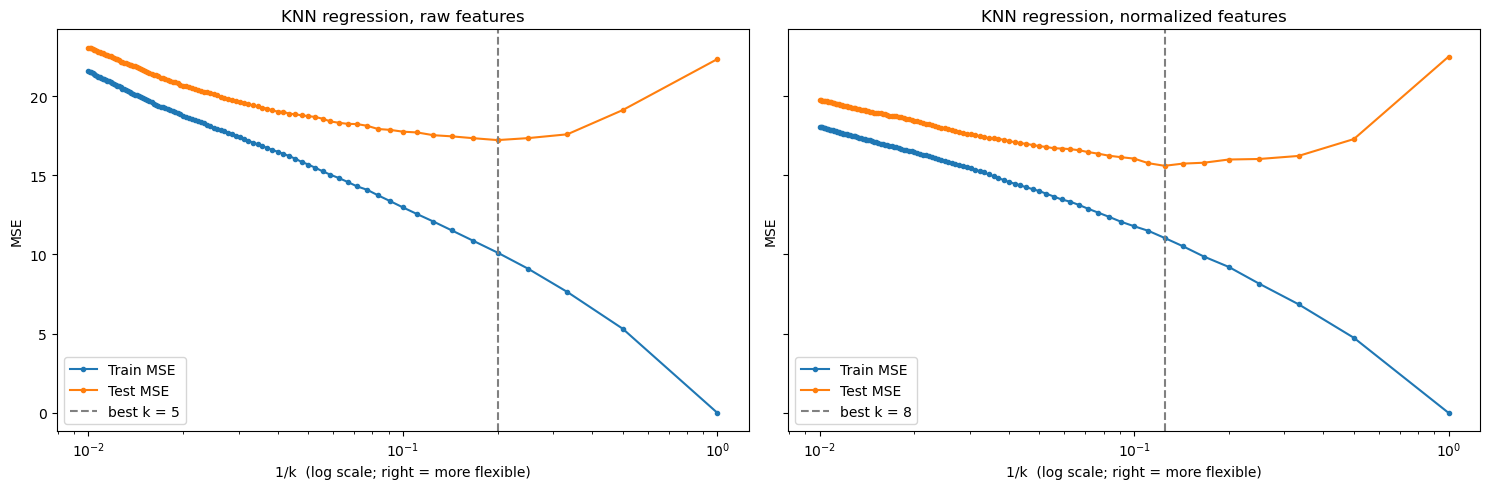

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (name, tr, te) in zip(axes, [("Raw features", raw_tr, raw_te),
                                     ("Normalized features", norm_tr, norm_te)]):
    k_best = best[name][0]
    ax.plot(1 / ks, tr, marker="o", ms=3, label="Train MSE")
    ax.plot(1 / ks, te, marker="o", ms=3, label="Test MSE")
    ax.axvline(1 / k_best, color="gray", ls="--", label=f"best k = {k_best}")
    ax.set_xscale("log")
    ax.set_xlabel("1/k  (log scale; right = more flexible)")
    ax.set_ylabel("MSE")
    ax.set_title(f"KNN regression, {name.lower()}")
    ax.legend()
plt.tight_layout()
plt.show()

With raw features the best k is 5 (test MSE 17.22), and with normalized features the best k is 8 (test MSE 15.60). Normalizing helps because without it, V and RH have the largest ranges and dominate the distance. In both plots the training error goes to 0 at k = 1 while the test error is lowest around k = 5 to 8, which is the usual bias-variance tradeoff.

### 1(j) KNN vs. the best linear regression model

In [60]:
comparison = pd.DataFrame({
    "Test MSE": [a_test, b_test, best["Raw features"][2], best["Normalized features"][2]],
}, index=["Linear (A)", "Linear + interactions + quadratics (B)",
          f"KNN raw (k={best['Raw features'][0]})",
          f"KNN normalized (k={best['Normalized features'][0]})"])
comparison

,Test MSE
Linear (A),21.7414
Linear + interactions + quadratics (B),19.0829
KNN raw (k=5),17.2225
KNN normalized (k=8),15.5992


The best linear model (Model B) has a test MSE of 19.08, while the best KNN (normalized, k = 8) has 15.60, so KNN predicts better here. With only 4 predictors and about 6,700 training points, KNN has enough close neighbors to capture nonlinear patterns that the quadratic model misses. The regression model is still easier to interpret, since it shows how each variable affects the output.

## Problem 2: ISLR 2.4.1

(a) Better. With a very large n and few predictors, a flexible method can fit the data closely without much risk of overfitting.

(b) Worse. With many predictors and few observations, a flexible method is likely to overfit.

(c) Better. An inflexible method would have high bias when the true relationship is highly non-linear.

(d) Worse. When the error variance is very high, a flexible method tends to fit the noise, which increases variance.

## Problem 3: ISLR 2.4.7

(a) Euclidean distance from each observation to the test point (0, 0, 0):

In [64]:
islr = pd.DataFrame({
    "X1": [0, 2, 0, 0, -1, 1],
    "X2": [3, 0, 1, 1, 0, 1],
    "X3": [0, 0, 3, 2, 1, 1],
    "Y": ["Red", "Red", "Red", "Green", "Green", "Red"],
}, index=pd.Index(range(1, 7), name="Obs."))
islr["Distance to (0,0,0)"] = np.sqrt((islr[["X1", "X2", "X3"]] ** 2).sum(axis=1))
islr.sort_values("Distance to (0,0,0)")

,X1,X2,X3,Y,"Distance to (0,0,0)"
Obs.,,,,,
5,-1,0,1,Green,1.4142
6,1,1,1,Red,1.7321
2,2,0,0,Red,2.0000
4,0,1,2,Green,2.2361
1,0,3,0,Red,3.0000
3,0,1,3,Red,3.1623


(b) With K = 1, the nearest neighbor is observation 5 (distance ≈ 1.41), which is Green, so the prediction is Green.

(c) With K = 3, the nearest neighbors are observations 5 (Green), 6 (Red) and 2 (Red), so the prediction is Red.

(d) Small. A small K gives a more flexible decision boundary, which is what we need to follow a highly non-linear Bayes boundary. A large K would make the boundary too smooth.

## References

- Tüfekci, P. (2014). Prediction of full load electrical power output of a base load operated combined cycle power plant using machine learning methods. *International Journal of Electrical Power & Energy Systems*, 60, 126–140.
- UCI Machine Learning Repository: Combined Cycle Power Plant Data Set.
- James, G., Witten, D., Hastie, T., & Tibshirani, R. *An Introduction to Statistical Learning*.